In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

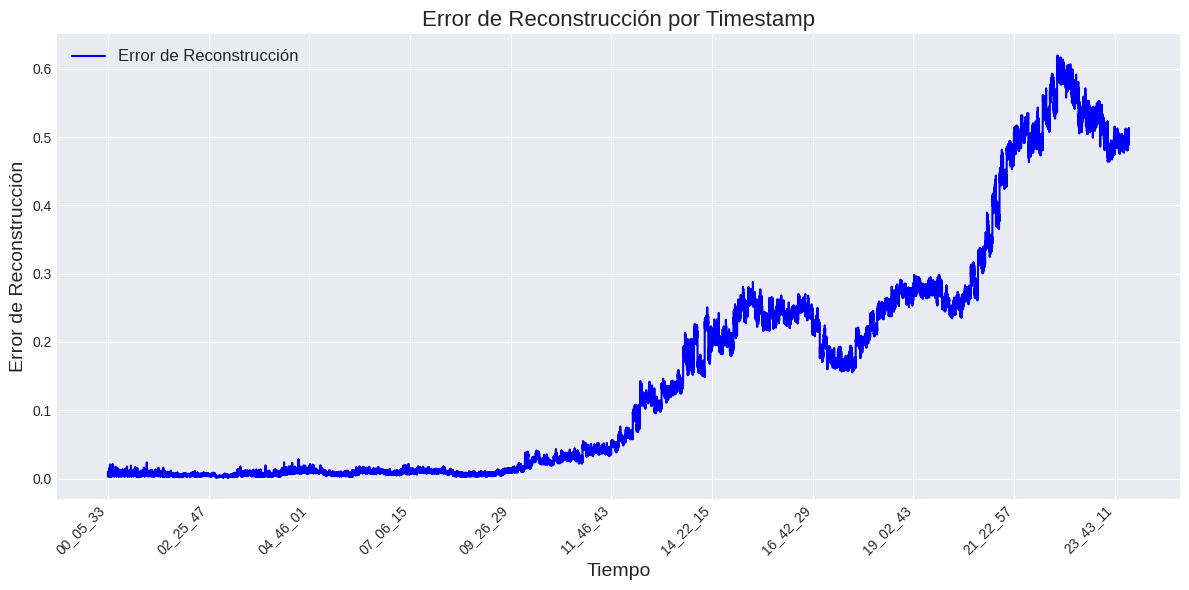

In [8]:
# Leer todos los archivos CSV con el patrón "reconstruction_error_batch"
file_pattern = "output/reconstruction_error_batch*.csv"
csv_files = glob.glob(file_pattern)

# Combinar los datos de todos los archivos en un solo DataFrame
data_frames = [pd.read_csv(file) for file in csv_files]
combined_data = pd.concat(data_frames, ignore_index=True)

# Asegurar que los datos estén ordenados por Timestamp
combined_data_sorted = combined_data.sort_values(by='Timestamp', ignore_index=True)

# Crear una columna para el eje X solo con los cambios de Timestamp después de ordenar
combined_data_sorted['Timestamp_Simplified'] = combined_data_sorted['Timestamp'].where(
    combined_data_sorted['Timestamp'] != combined_data_sorted['Timestamp'].shift(), None
)

# Configurar el estilo de la gráfica para alta calidad
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))

# Graficar los datos ordenados
plt.plot(combined_data_sorted['Error_Reconstrucción'], label='Error de Reconstrucción', linewidth=1.5, color='blue')

# Configurar el eje X con etiquetas simplificadas para evitar solapamiento
xticks_indices = combined_data_sorted.index[~combined_data_sorted['Timestamp_Simplified'].isna()]
xticks_labels = combined_data_sorted['Timestamp_Simplified'].dropna()

# Reducir la frecuencia de las etiquetas para mayor claridad
step = max(len(xticks_labels) // 10, 1)
xticks_indices = xticks_indices[::step]
xticks_labels = xticks_labels[::step]

plt.xticks(
    ticks=xticks_indices,
    labels=xticks_labels,
    rotation=45,
    fontsize=10,
    ha='right'
)

# Etiquetas y título
plt.xlabel('Tiempo', fontsize=14)
plt.ylabel('Error de Reconstrucción', fontsize=14)
plt.title('Error de Reconstrucción por Timestamp', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

# Guardar la gráfica como imagen de alta calidad
plt.savefig("output/reconstruction_error_plot_sorted.png", dpi=300)
plt.show()
